Learning rate sweep. Run vanilla gradient descent on the Rosenbrock function with learning rates [0.0001, 0.0005, 0.001, 0.005, 0.01]. Plot or print the final loss after 5000 steps for each. Find the largest learning rate that still converges.

In [1]:
def rosenbrock(params):
    x,y=params
    return (1-x)**2 +100*(y-(x)**2)**2

In [2]:
class GradientDescent:
    def __init__(self,lr):
        self.lr=lr
    def step(self,params,grads):
        return [
            p-self.lr*g for p,g in zip(params,grads)
        ]
        

In [3]:
def rosenbrock_gradient(params):
    x,y=params
    df_dx=-2*(1-x) + 200 * (y-x**2)*(-2*x)
    df_dy=200*(y-x**2)
    return [df_dx,df_dy]

In [8]:
learning_rates = [0.0001, 0.0005, 0.001, 0.005, 0.01]

start_pos = [-1.2, 1]

for lr in learning_rates:
    gd = GradientDescent(lr)
    params = start_pos.copy()

    try:
        for step in range(5000):
            grads = rosenbrock_gradient(params)
            params = gd.step(params, grads)

        loss = rosenbrock(params)

        print(f"lr = {lr}: final loss = {loss}")

    except OverflowError:
        print(f"lr = {lr}: DIVERGED (overflow)")

lr = 0.0001: final loss = 2.305717695096495
lr = 0.0005: final loss = 0.042951593583091884
lr = 0.001: final loss = 0.0037609231221175142
lr = 0.005: final loss = 0.7880389441648865
lr = 0.01: DIVERGED (overflow)


Momentum comparison. Run SGD with momentum values [0.0, 0.5, 0.9, 0.99] on the Rosenbrock function. Track the loss at every step. Which momentum value converges fastest? Which overshoots?

In [9]:
import torch
import matplotlib.pyplot as plt

momentums = [0.0, 0.5, 0.9, 0.99]

losses = {}

for momentum in momentums:

    # Start from the same point for fair comparison
    params = torch.tensor([-1.2, 1.0], dtype=torch.float32, requires_grad=True)

    optimizer = torch.optim.SGD(
        [params],
        lr=0.001,
        momentum=momentum
    )

    loss_history = []

    for step in range(5000):

        optimizer.zero_grad()

        x, y = params

        loss = (1 - x)**2 + 100 * (y - x**2)**2

        loss.backward()
        optimizer.step()

        loss_history.append(loss.item())

    losses[momentum] = loss_history

    print(
        f"momentum={momentum}, "
        f"final loss={loss_history[-1]:.6f}"
    )

momentum=0.0, final loss=0.003764
momentum=0.5, final loss=0.000057
momentum=0.9, final loss=0.000000
momentum=0.99, final loss=0.000000


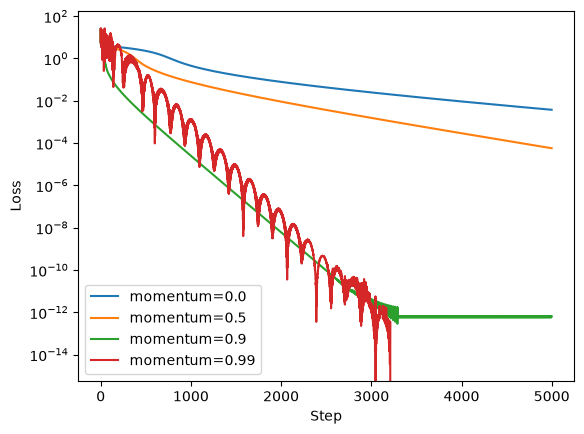

In [10]:
for momentum in momentums:
    plt.plot(losses[momentum], label=f"momentum={momentum}")

plt.yscale("log")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.legend()
plt.show()

Saddle point escape. Define the function f(x, y) = x^2 - y^2 (a saddle point at the origin). Start at (0.01, 0.01). Compare how vanilla GD, SGD with momentum, and Adam behave. Which escapes the saddle point?

In [11]:
import torch
import matplotlib.pyplot as plt

def saddle_loss(params):
    x, y = params
    return x**2 - y**2


optimizers = ["SGD", "Momentum", "Adam"]
losses = {}
trajectories = {}

for opt_name in optimizers:

    # Same starting point for every optimizer
    params = torch.tensor(
        [0.01, 0.01],
        dtype=torch.float32,
        requires_grad=True
    )

    if opt_name == "SGD":
        optimizer = torch.optim.SGD([params], lr=0.01)

    elif opt_name == "Momentum":
        optimizer = torch.optim.SGD(
            [params],
            lr=0.01,
            momentum=0.9
        )

    elif opt_name == "Adam":
        optimizer = torch.optim.Adam(
            [params],
            lr=0.01
        )

    loss_history = []
    trajectory = []

    for step in range(1000):

        optimizer.zero_grad()

        loss = saddle_loss(params)

        loss.backward()

        optimizer.step()

        loss_history.append(loss.item())
        trajectory.append(params.detach().numpy().copy())

    losses[opt_name] = loss_history
    trajectories[opt_name] = trajectory

    print(
        opt_name,
        "final position =", params.detach().numpy(),
        "final loss =", loss.item()
    )

SGD final position = [1.6829677e-11 3.9826422e+06] final loss = -15245520142336.0
Momentum final position = [-1.3849471e-25            inf] final loss = -inf
Adam final position = [-3.2777417e-27  1.5840885e+01] final loss = -250.45030212402344


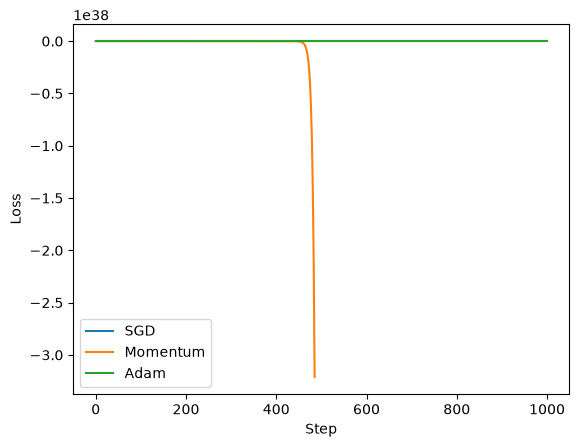

In [12]:
for name in optimizers:
    plt.plot(losses[name], label=name)

plt.xlabel("Step")
plt.ylabel("Loss")
plt.legend()
plt.show()

Implement learning rate decay. Add an exponential decay schedule to the GradientDescent class: lr = lr_0 * 0.999^step. Compare convergence with and without decay on the Rosenbrock function.

In [18]:
class GradientDescent:
    def __init__(self,lr):
        self.lr=lr
    def step(self,params,grads):
        return [
            p-self.lr*g for p,g in zip(params,grads)
        ]

In [ ]:
class GradientDescentExponentialdecay:
    def __init__(self, lr):
        self.lr_0 = lr
        self.step_num = 0

    def step(self, params, grads):
        lr = self.lr_0 * 0.999**self.step_num

        self.step_num += 1

        return [
            p - lr*g for p,g in zip(params,grads)
        ]

In [26]:
def optimize(optimizer, func, grad_func, start, steps=5000):
    params = list(start)
    history = [params[:]]
    for _ in range(steps):
        grads = grad_func(params)
        params = optimizer.step(params, grads)
        history.append(params[:])
    return history

start = [-1.0, 1.0]

gd_history1 = optimize(GradientDescent(lr=0.0005), rosenbrock, rosenbrock_gradient, start)
gd_history2 = optimize(GradientDescentExponentialdecay(lr=0.0005,st=1), rosenbrock, rosenbrock_gradient, start)


In [27]:
print("Without decay:", rosenbrock(gd_history1[-1]))
print("With decay:", rosenbrock(gd_history2[-1]))

Without decay: 0.04083384590441455
With decay: 2.1151610745534724


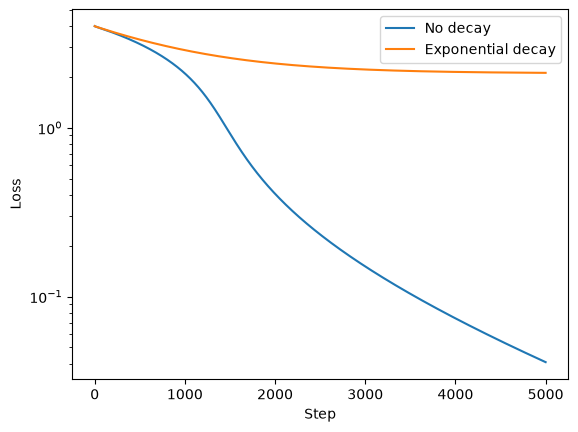

In [28]:
import matplotlib.pyplot as plt

loss1 = [rosenbrock(p) for p in gd_history1]
loss2 = [rosenbrock(p) for p in gd_history2]

plt.plot(loss1, label="No decay")
plt.plot(loss2, label="Exponential decay")

plt.yscale("log")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.legend()
plt.show()